<a href="https://colab.research.google.com/github/kavya5cloud/dark-universe-lab/blob/main/02_WeakLensingSimulator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

plt.rcParams["figure.figsize"] = (8,8)

In [3]:
np.random.seed(42)

mass_map = np.random.normal(
    0,
    1,
    (256,256)
)

mass_map = gaussian_filter(
    mass_map,
    sigma=10
)

mass_map = (
    mass_map - mass_map.mean()
)/mass_map.std()

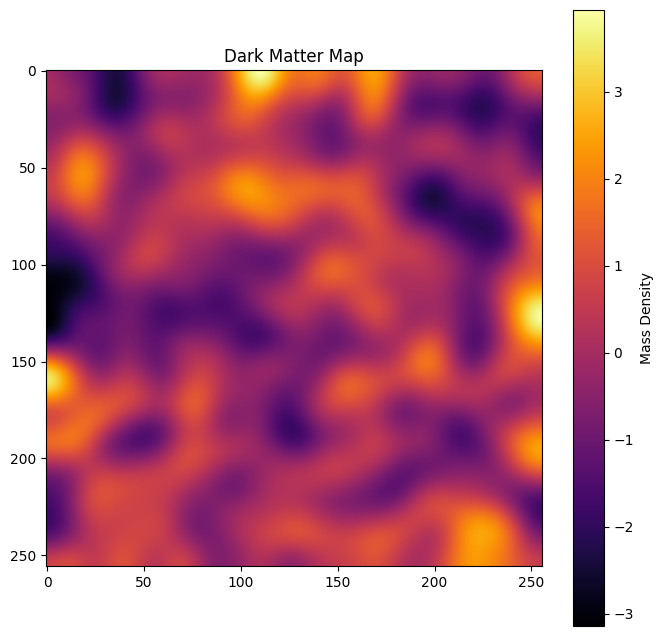

In [4]:
plt.imshow(
    mass_map,
    cmap="inferno"
)

plt.colorbar(label="Mass Density")
plt.title("Dark Matter Map")
plt.show()

In [5]:
fft_mass = np.fft.fft2(mass_map)

nx, ny = mass_map.shape

kx = np.fft.fftfreq(nx)
ky = np.fft.fftfreq(ny)

kx, ky = np.meshgrid(kx, ky)

k_squared = kx**2 + ky**2

k_squared[0,0] = 1

In [6]:
potential_fft = fft_mass / k_squared

potential_fft[0,0] = 0

potential = np.real(
    np.fft.ifft2(
        potential_fft
    )
)

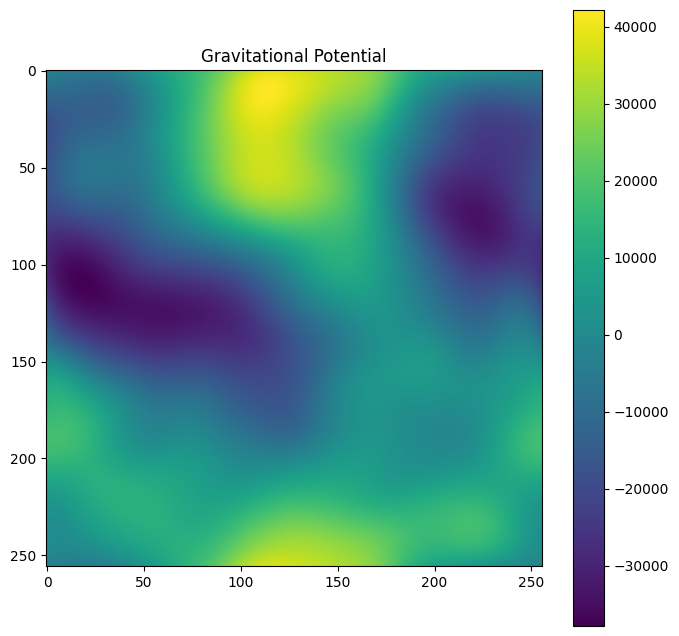

In [7]:
plt.imshow(
    potential,
    cmap="viridis"
)

plt.colorbar()
plt.title("Gravitational Potential")
plt.show()

In [8]:
grad_y, grad_x = np.gradient(potential)

gxx = np.gradient(
    grad_x,
    axis=1
)

gyy = np.gradient(
    grad_y,
    axis=0
)

gxy = np.gradient(
    grad_x,
    axis=0
)

In [9]:
gamma1 = 0.5 * (gxx - gyy)

gamma2 = gxy

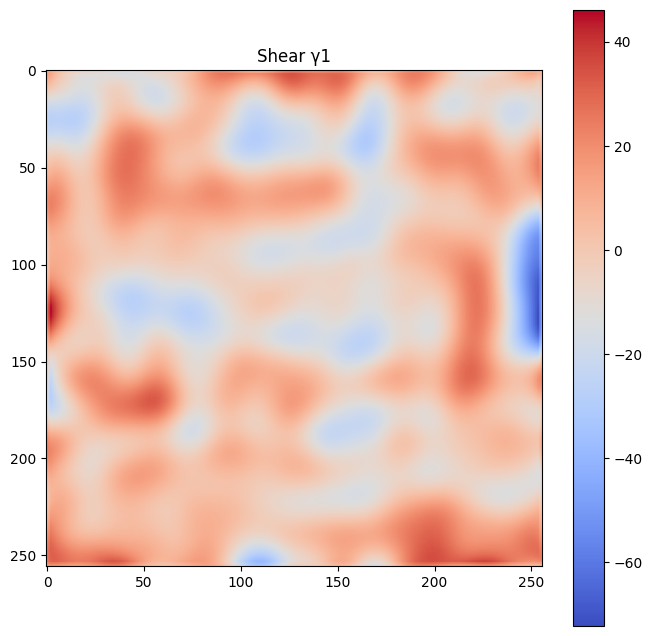

In [10]:
plt.imshow(
    gamma1,
    cmap="coolwarm"
)

plt.colorbar()
plt.title("Shear γ1")
plt.show()

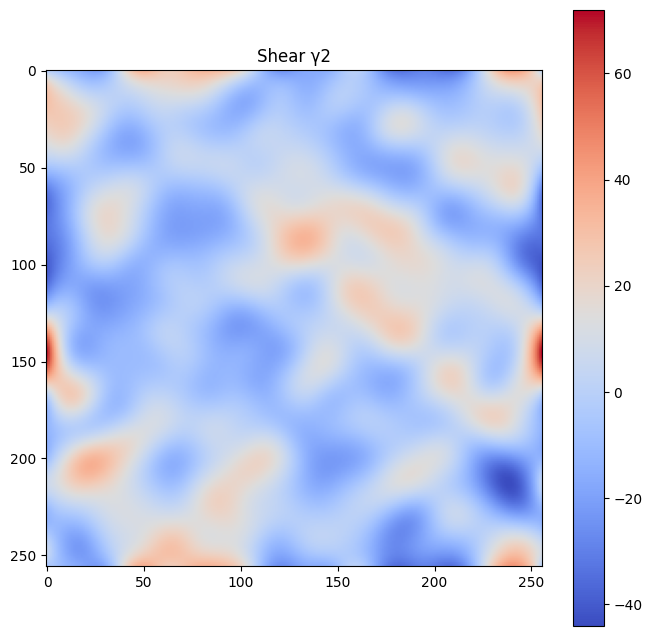

In [11]:
plt.imshow(
    gamma2,
    cmap="coolwarm"
)

plt.colorbar()
plt.title("Shear γ2")
plt.show()

In [12]:
shear_mag = np.sqrt(
    gamma1**2 +
    gamma2**2
)

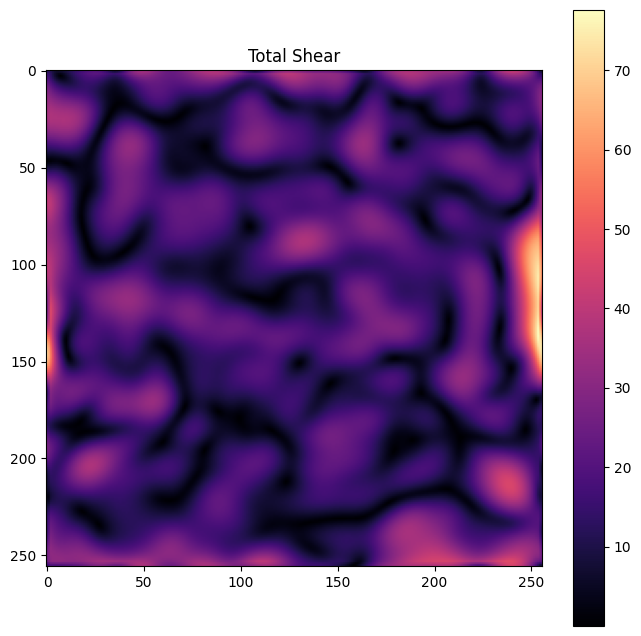

In [13]:
plt.imshow(
    shear_mag,
    cmap="magma"
)

plt.colorbar()
plt.title("Total Shear")
plt.show()

In [14]:
noise = np.random.normal(
    0,
    0.05,
    shear_mag.shape
)

observed_shear = (
    shear_mag +
    noise
)

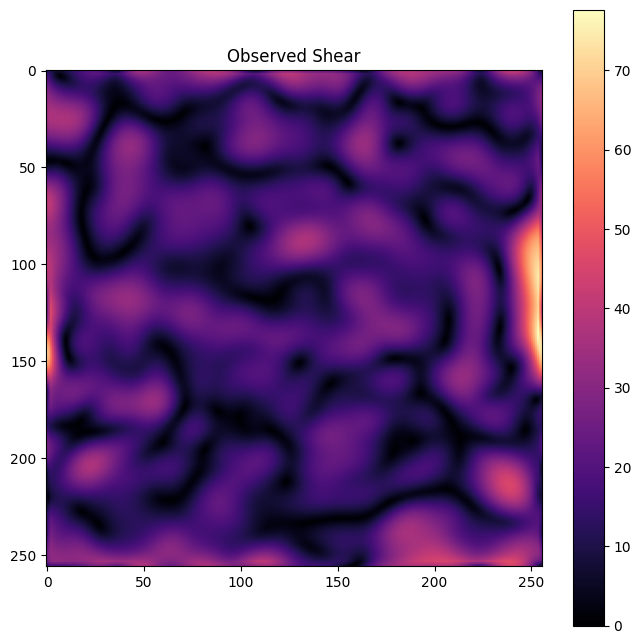

In [15]:
plt.imshow(
    observed_shear,
    cmap="magma"
)

plt.colorbar()
plt.title("Observed Shear")
plt.show()